In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../Materials/sales_dataset (1).csv')

In [3]:
df

,order_id,order_date,customer_id,city,segment,product_category,payment_method,quantity,unit_price,discount,shipping_cost,delivery_days,revenue,profit,is_returned,rating
0,1,2023-04-13,17542,Tanta,Consumer,Furniture,Online,2,160.71,0.11,16.24,1,286.07,31.54,0,4
1,2,2024-03-11,12011,Giza,Corporate,Technology,Card,8,205.20,0.16,4.30,5,1378.97,14.56,0,4
2,3,2023-09-28,13373,Alexandria,Consumer,Technology,Online,3,202.32,0.05,15.22,5,576.60,215.75,0,3
3,4,2023-04-17,17357,Cairo,Corporate,Technology,Online,3,182.33,0.16,5.66,5,459.47,81.50,0,2
4,5,2023-03-13,11289,Alexandria,Home Office,Furniture,Online,7,128.27,0.11,8.52,6,799.13,204.12,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2023-12-04,14775,Alexandria,Corporate,Office Supplies,Online,4,37.69,0.10,0.76,1,135.69,23.70,0,5
4996,4997,2023-06-15,13409,Alexandria,Corporate,Furniture,Card,4,168.07,0.01,15.65,4,665.58,275.35,0,4
4997,4998,2024-01-18,10689,Cairo,Consumer,Furniture,Card,5,139.61,0.01,19.61,1,691.09,211.33,0,4
4998,4999,2024-01-11,17028,Giza,Corporate,Office Supplies,Card,3,51.67,0.05,6.38,6,147.27,34.01,0,1


In [4]:
import matplotlib.pyplot as plt

In [5]:
x = df['city'].value_counts()

In [6]:
x.values

array([1405, 1133,  894,  488,  407,  341,  332])

In [7]:
x.index

Index(['Cairo', 'Giza', 'Alexandria', 'Luxor', 'Tanta', 'Mansoura', 'Aswan'], dtype='object', name='city')

In [8]:
y = df['city'].value_counts().reset_index() # to convert the series to a dataframe reset_index() is used for that 

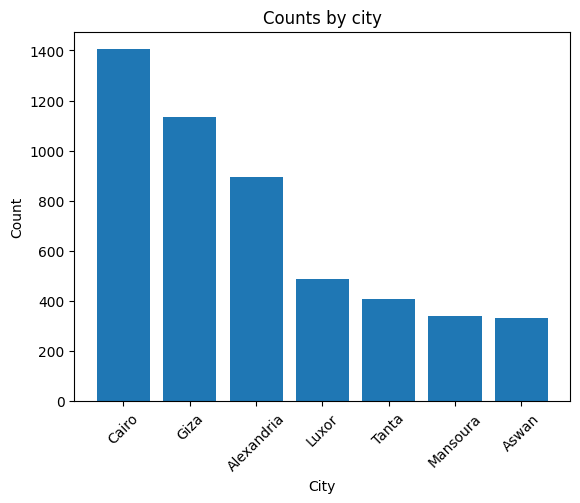

In [9]:
plt.figure()
plt.bar(y['city'], y['count'])
plt.title('Counts by city')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=45) # the rotation of the x-axis labels
plt.show()

In [10]:
segments_count = df['segment'].value_counts().reset_index()
segments_count.columns = ['segment', 'count']

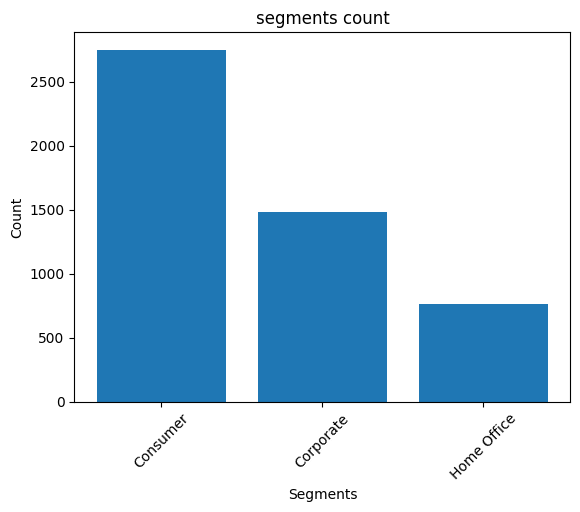

In [11]:
plt.figure()
plt.bar(segments_count['segment'], segments_count['count'])
plt.title('segments count')
plt.xlabel('Segments')
plt.ylabel('Count')
plt.xticks(rotation=45) # the rotation of the x-axis labels
plt.show()

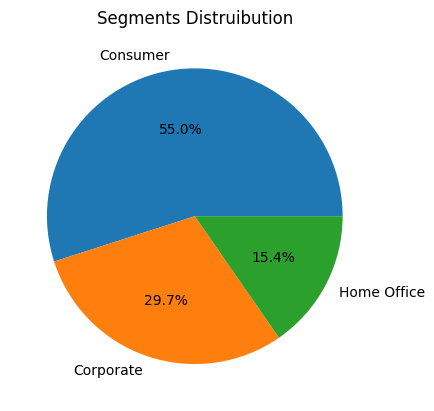

In [12]:
plt.figure()
plt.pie(segments_count['count'], labels=segments_count['segment'], autopct='%1.1f%%')
plt.title('Segments Distruibution')
plt.show()

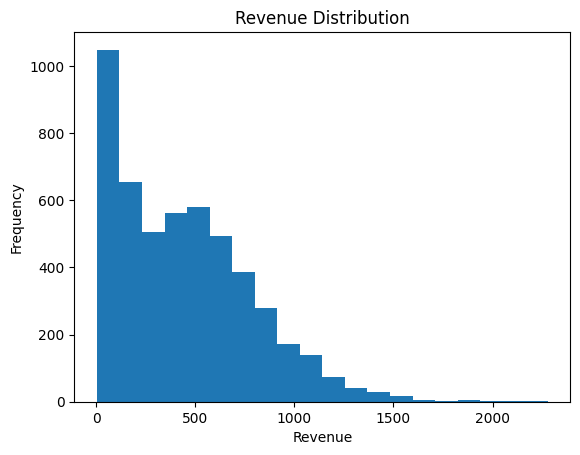

In [13]:
plt.figure()
plt.hist(df['revenue'], bins=20)
plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

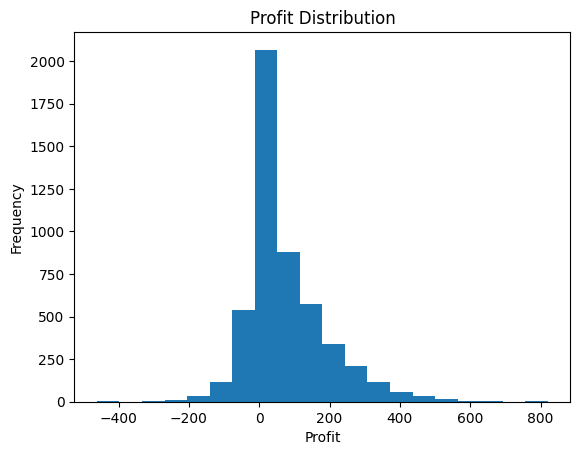

In [14]:
plt.figure()
plt.hist(df['profit'], bins=20)
plt.title('Profit Distribution')
plt.xlabel('Profit')    
plt.ylabel('Frequency')
plt.show()

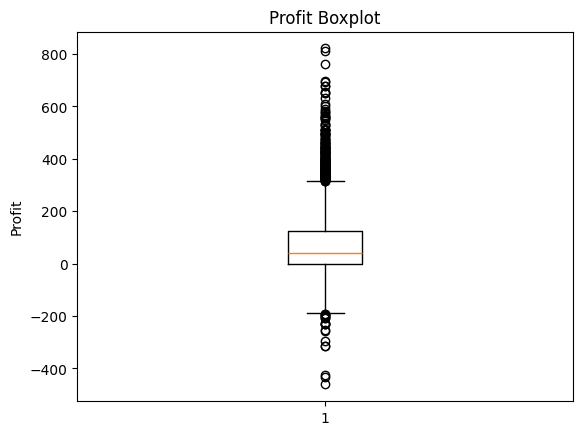

In [15]:
plt.figure()
plt.boxplot(df['profit'])
plt.title('Profit Boxplot')
plt.ylabel('Profit')
plt.show()

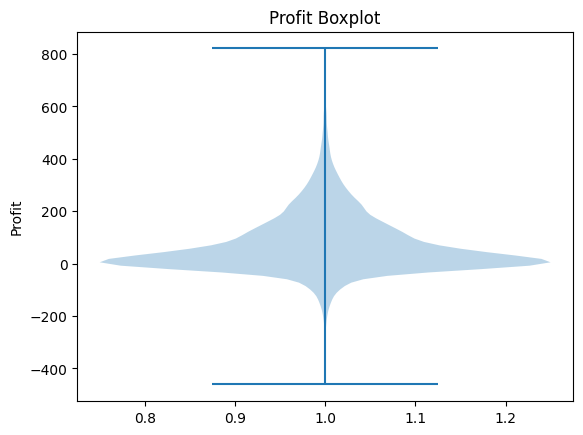

In [16]:
plt.figure()
plt.violinplot(df['profit'])
plt.title('Profit Boxplot')
plt.ylabel('Profit')
plt.show()

In [17]:
revenue_by_category = df.groupby('product_category')['profit'].sum().reset_index()

([0, 1, 2],
 [Text(0, 0, 'Furniture'),
  Text(1, 0, 'Office Supplies'),
  Text(2, 0, 'Technology')])

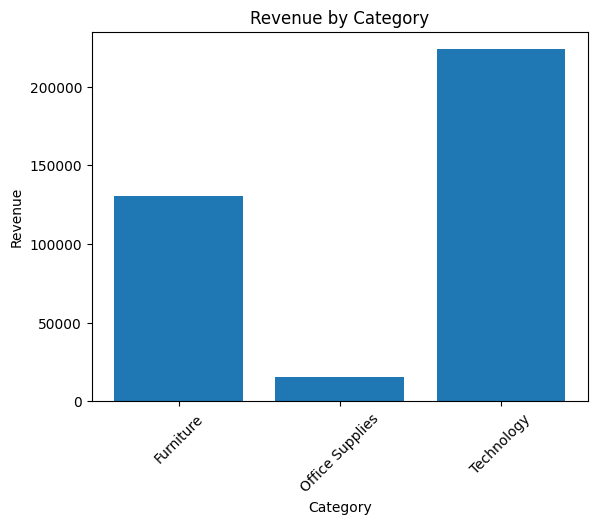

In [18]:
plt.figure()
plt.bar(revenue_by_category['product_category'], revenue_by_category['profit'])
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

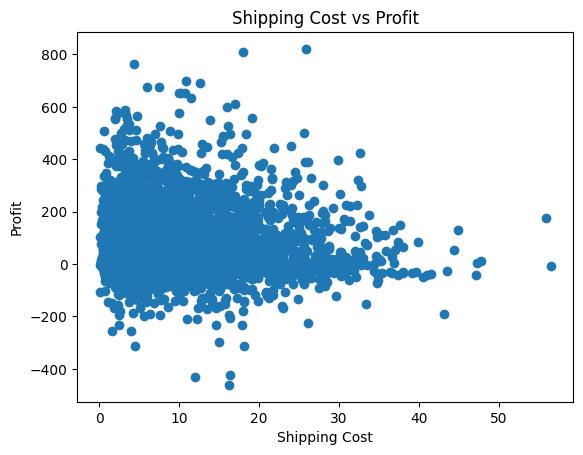

In [20]:
plt.figure()
plt.scatter(df['shipping_cost'], df['profit'])
plt.title('Shipping Cost vs Profit')
plt.xlabel('Shipping Cost')
plt.ylabel('Profit')
plt.show()

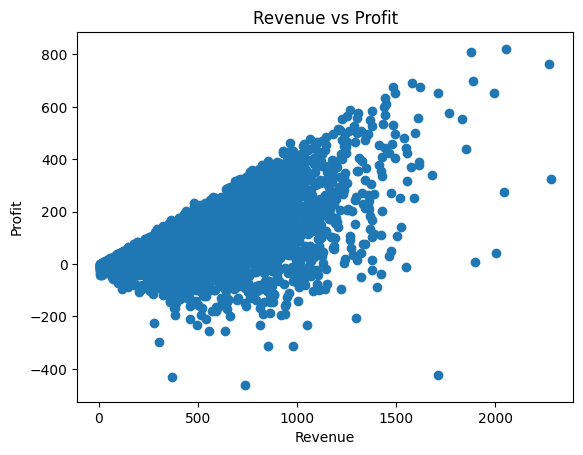

In [21]:
plt.figure()
plt.scatter(df['revenue'], df['profit'])
plt.title('Revenue vs Profit')
plt.xlabel('Revenue')
plt.ylabel('Profit')
plt.show()

In [ ]:
sum_of_returned = df.groupby('is_returned')['shipping_cost'].sum().reset_index()
# sum_of_returned['is_returned'] = sum_of_returned['is_returned'].map({0:'not returned', 1:'returned'})

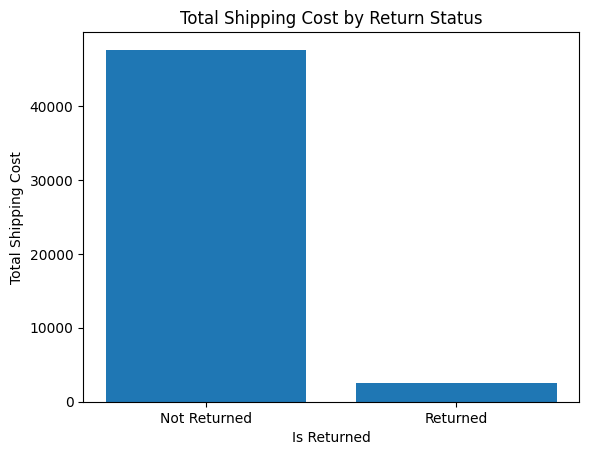

In [26]:
plt.figure()
plt.bar(sum_of_returned['is_returned'], sum_of_returned['shipping_cost'])
plt.title('Total Shipping Cost by Return Status')
plt.xlabel('Is Returned')
plt.ylabel('Total Shipping Cost')
plt.xticks([0, 1], ['Not Returned', 'Returned'])
plt.show()

In [27]:
profit_by_city = df.groupby('city')['profit'].sum().reset_index()
profit_by_city

,city,profit
0,Alexandria,67379.17
1,Aswan,29506.70
2,Cairo,103204.59
3,Giza,81188.03
4,Luxor,33832.57
5,Mansoura,25276.60
6,Tanta,29423.17


AttributeError: module 'matplotlib.pyplot' has no attribute 'tittle'

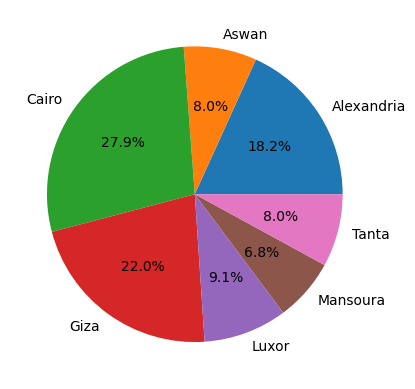

In [28]:
plt.show()
plt.pie(profit_by_city['profit'], labels=profit_by_city['city'], autopct='%1.1f%%')
plt.tittle('Profit Distribution by City')
plt.show()

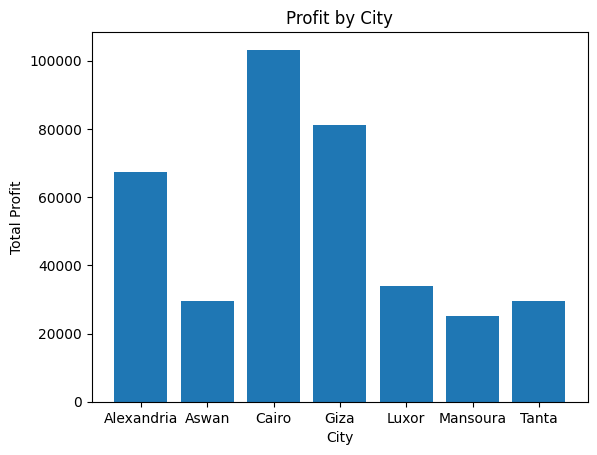

In [29]:
plt.figure()
plt.bar(profit_by_city['city'], profit_by_city['profit'])
plt.title('Profit by City')
plt.xlabel('City')
plt.ylabel('Total Profit')
plt.show()

In [30]:
profit_by_payment_method = df.groupby('payment_method')['profit'].sum().reset_index()
profit_by_payment_method

,payment_method,profit
0,Card,217477.64
1,Cash,42268.73
2,Online,110064.46


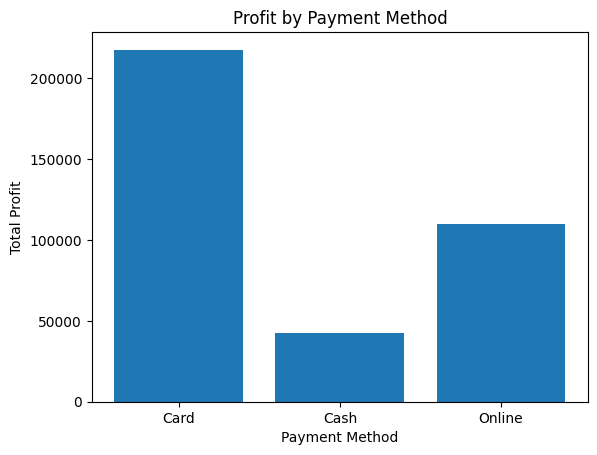

In [32]:
plt.figure()
plt.bar(profit_by_payment_method['payment_method'], profit_by_payment_method['profit'])
plt.title('Profit by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Profit')
plt.show()

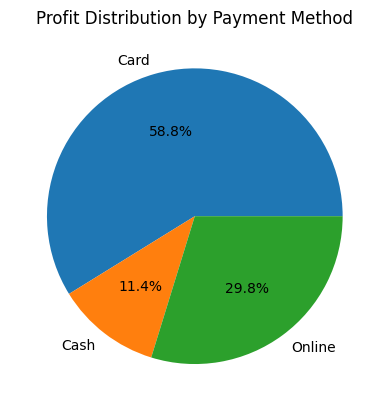

In [33]:
plt.figure()
plt.pie(profit_by_payment_method['profit'], labels=profit_by_payment_method['payment_method'], autopct='%1.1f%%')
plt.title('Profit Distribution by Payment Method')
plt.show()

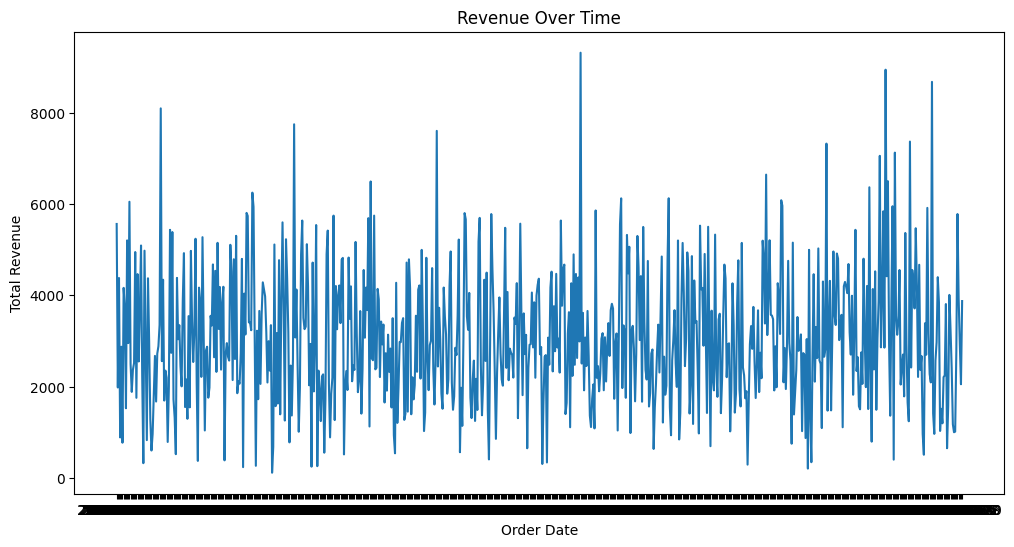

In [34]:
orders_revenue_over_time = df.groupby('order_date')['revenue'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(orders_revenue_over_time['order_date'], orders_revenue_over_time['revenue'])
plt.title('Revenue Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Revenue')
plt.show()

In [35]:
df['order_date'] = pd.to_datetime(df['order_date'])

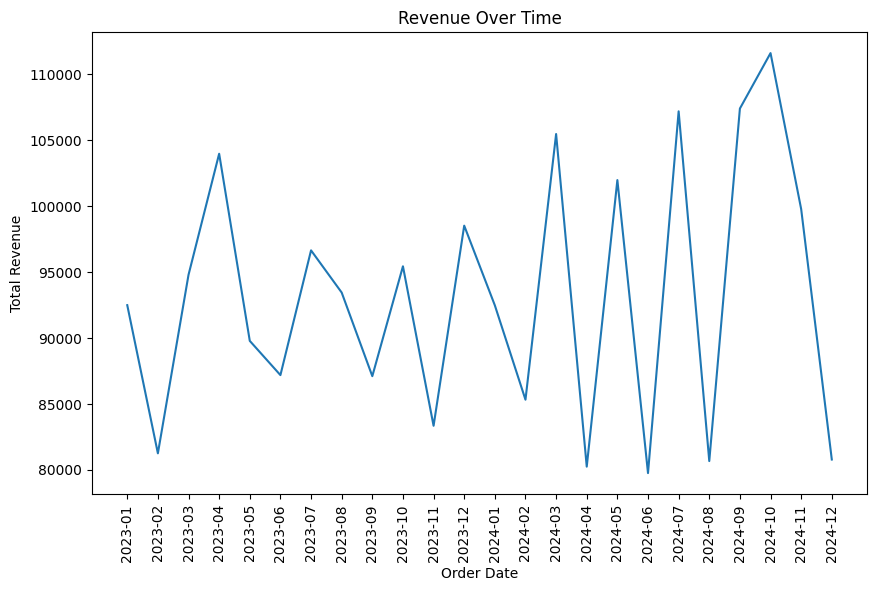

In [37]:
orders_revenue_over_time = df.groupby(df['order_date'].dt.to_period('M'))['revenue'].sum().reset_index()
orders_revenue_over_time

plt.figure(figsize=(10, 6))
plt.plot(orders_revenue_over_time['order_date'].astype(str), orders_revenue_over_time['revenue'])
plt.title('Revenue Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Revenue')
plt.xticks(rotation=90)
plt.show()  

In [38]:
df.corr(numeric_only=True)

,order_id,customer_id,quantity,unit_price,discount,shipping_cost,delivery_days,revenue,profit,is_returned,rating
order_id,1.000000,0.000427,-0.003297,-0.010845,0.014232,-0.008540,0.001330,-0.012858,-0.014783,0.004531,0.003127
customer_id,0.000427,1.000000,-0.004709,0.011485,-0.009924,-0.001018,-0.029615,0.008759,0.007091,-0.019557,0.004383
quantity,-0.003297,-0.004709,1.000000,-0.008552,-0.015983,0.004073,-0.014281,0.565630,0.330767,0.002334,-0.011325
unit_price,-0.010845,0.011485,-0.008552,1.000000,-0.001495,-0.005065,-0.024039,0.732052,0.398732,0.004698,0.013885
discount,0.014232,-0.009924,-0.015983,-0.001495,1.000000,0.027414,0.012852,-0.153413,-0.418175,0.005245,-0.016234
shipping_cost,-0.008540,-0.001018,0.004073,-0.005065,0.027414,1.000000,0.013093,-0.007150,-0.085543,0.008146,-0.007699
delivery_days,0.001330,-0.029615,-0.014281,-0.024039,0.012852,0.013093,1.000000,-0.035569,-0.025437,0.016489,0.019319
revenue,-0.012858,0.008759,0.565630,0.732052,-0.153413,-0.007150,-0.035569,1.000000,0.633458,-0.000912,-0.003518
profit,-0.014783,0.007091,0.330767,0.398732,-0.418175,-0.085543,-0.025437,0.633458,1.000000,-0.009428,0.013204
is_returned,0.004531,-0.019557,0.002334,0.004698,0.005245,0.008146,0.016489,-0.000912,-0.009428,1.000000,-0.032516


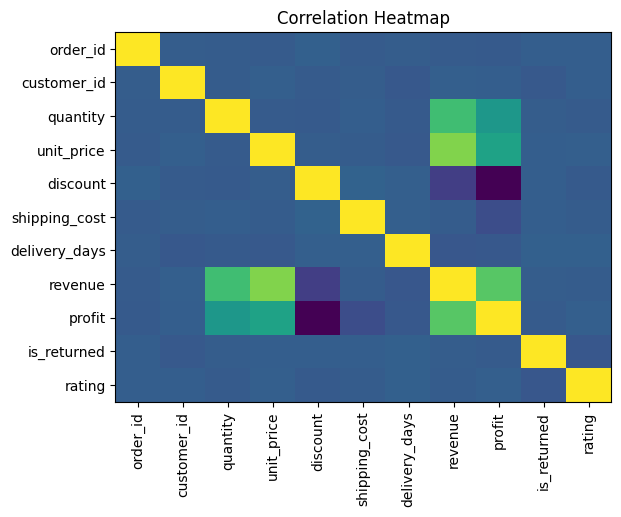

In [43]:
plt.figure()
plt.imshow(df.corr(numeric_only=True),aspect='auto')
plt.title('Correlation Heatmap')
plt.xticks(range(len(df.corr(numeric_only=True).columns)), df.corr(numeric_only=True).columns, rotation=90)
plt.yticks(range(len(df.corr(numeric_only=True).columns)), df.corr(numeric_only=True).columns)    
plt.show()